In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv(r"C:\Users\zizou\OneDrive\Desktop\stage 3ème\day 2\csvfiles\dataframefinale.csv", sep=";", encoding="utf-8-sig")
df


,dataloadingdate,ISIN,Libellé,Nombre de Titres,Montant,Echéance,Taux
0,01/07/2025,TN0008000739,"BTA 7,4% Fevrier 2030",1459.0,1.500,62.0,7.60
1,01/07/2025,TN0008000739,"BTA 7,4% Fevrier 2030",291.0,0.300,183.0,7.50
2,01/07/2025,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,50000.0,5.000,13.0,8.60
3,01/07/2025,TNMCPXLL1EE2,EMP NAT 2023 T4 CB TV,10000.0,1.000,7.0,8.60
4,01/07/2025,TN0008000606,"BTA 6,7% Avril 2028",5660.0,5.742,31.0,9.10
...,...,...,...,...,...,...,...
19939,31/12/2024,TN0008000812,"BTA 7,5% 13/12/2028",215.0,0.200,50.0,9.00
19940,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,5243.0,0.556,15.0,7.49
19941,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,28288.0,3.000,31.0,8.99
19942,31/12/2024,TNX0K9990B08,EMP NAT 2024 T2 CB TF,48701.0,5.165,31.0,8.99


In [32]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19944 entries, 0 to 19943
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   dataloadingdate   19944 non-null  object 
 1   ISIN              19944 non-null  object 
 2   Libellé           19944 non-null  object 
 3   Nombre de Titres  19944 non-null  float64
 4   Montant           19944 non-null  float64
 5   Echéance          19944 non-null  float64
 6   Taux              19944 non-null  float64
dtypes: float64(4), object(3)
memory usage: 1.1+ MB


In [33]:
df.describe()


,Nombre de Titres,Montant,Echéance,Taux
count,19944.000000,19944.000000,19944.000000,19944.000000
mean,8872.550592,4.867922,40.106548,8.625240
std,17043.278291,7.967361,61.110939,0.813669
min,1.000000,0.001000,0.000000,5.800000
25%,1073.000000,1.000000,10.000000,8.030000
50%,3128.500000,2.001000,20.000000,8.970000
75%,8742.000000,5.500000,32.000000,9.010000
max,200000.000000,100.000000,365.000000,10.750000


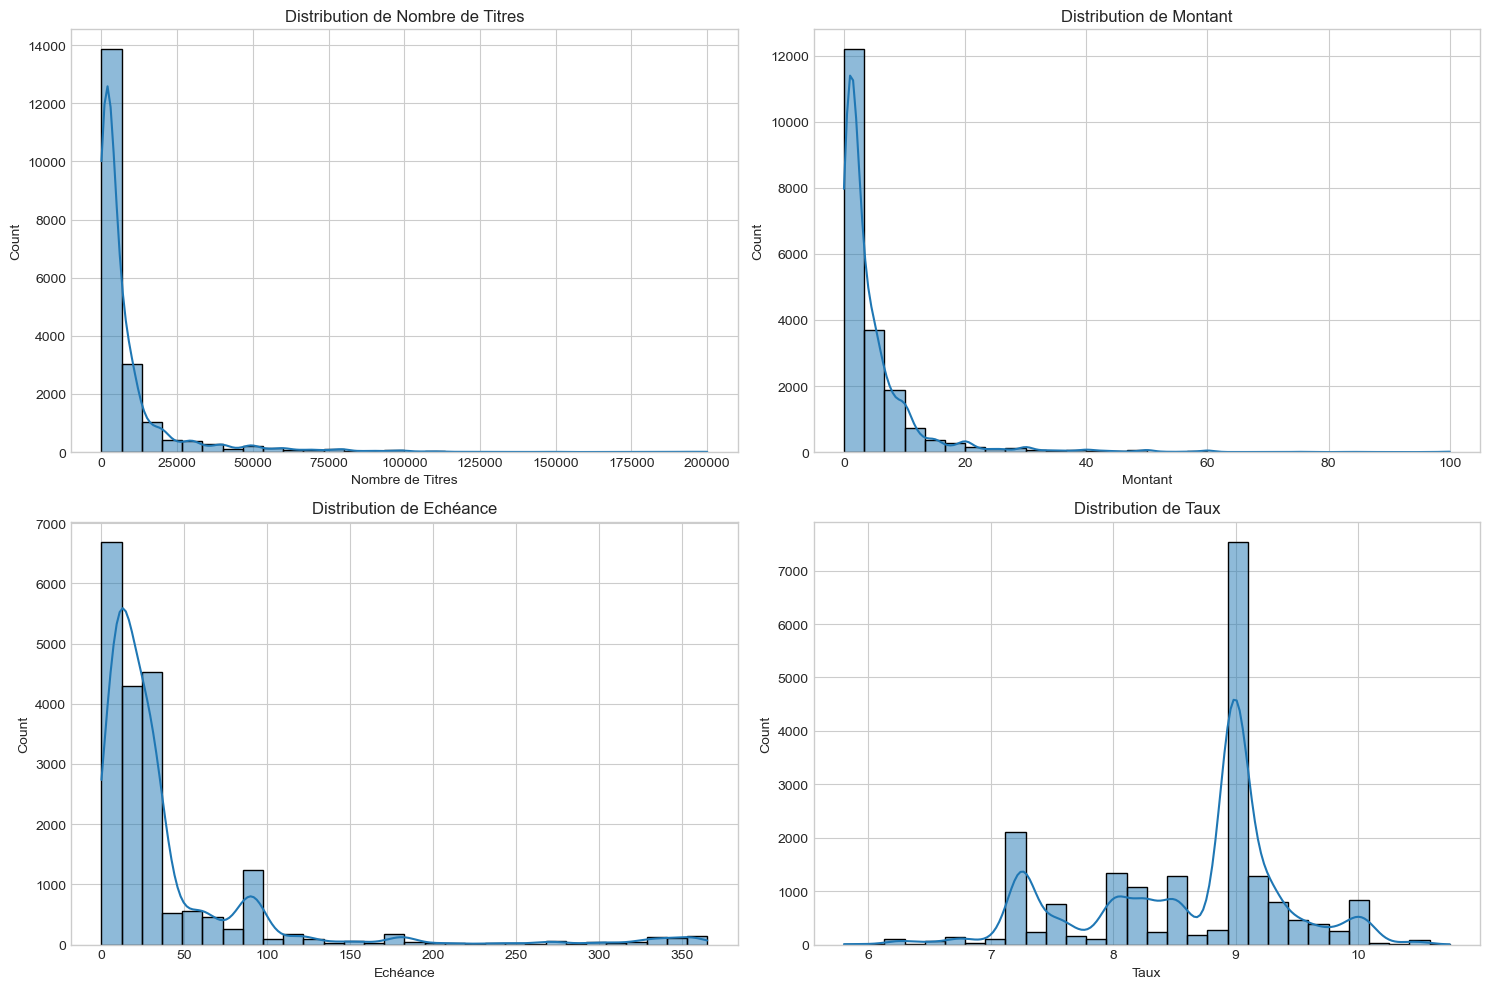

In [34]:
colonnes = ["Nombre de Titres", "Montant", "Echéance", "Taux"]

plt.figure(figsize=(15, 10))
for i, col in enumerate(colonnes):
    plt.subplot(2, 2, i+1)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f"Distribution de {col}")
plt.tight_layout()
plt.show()


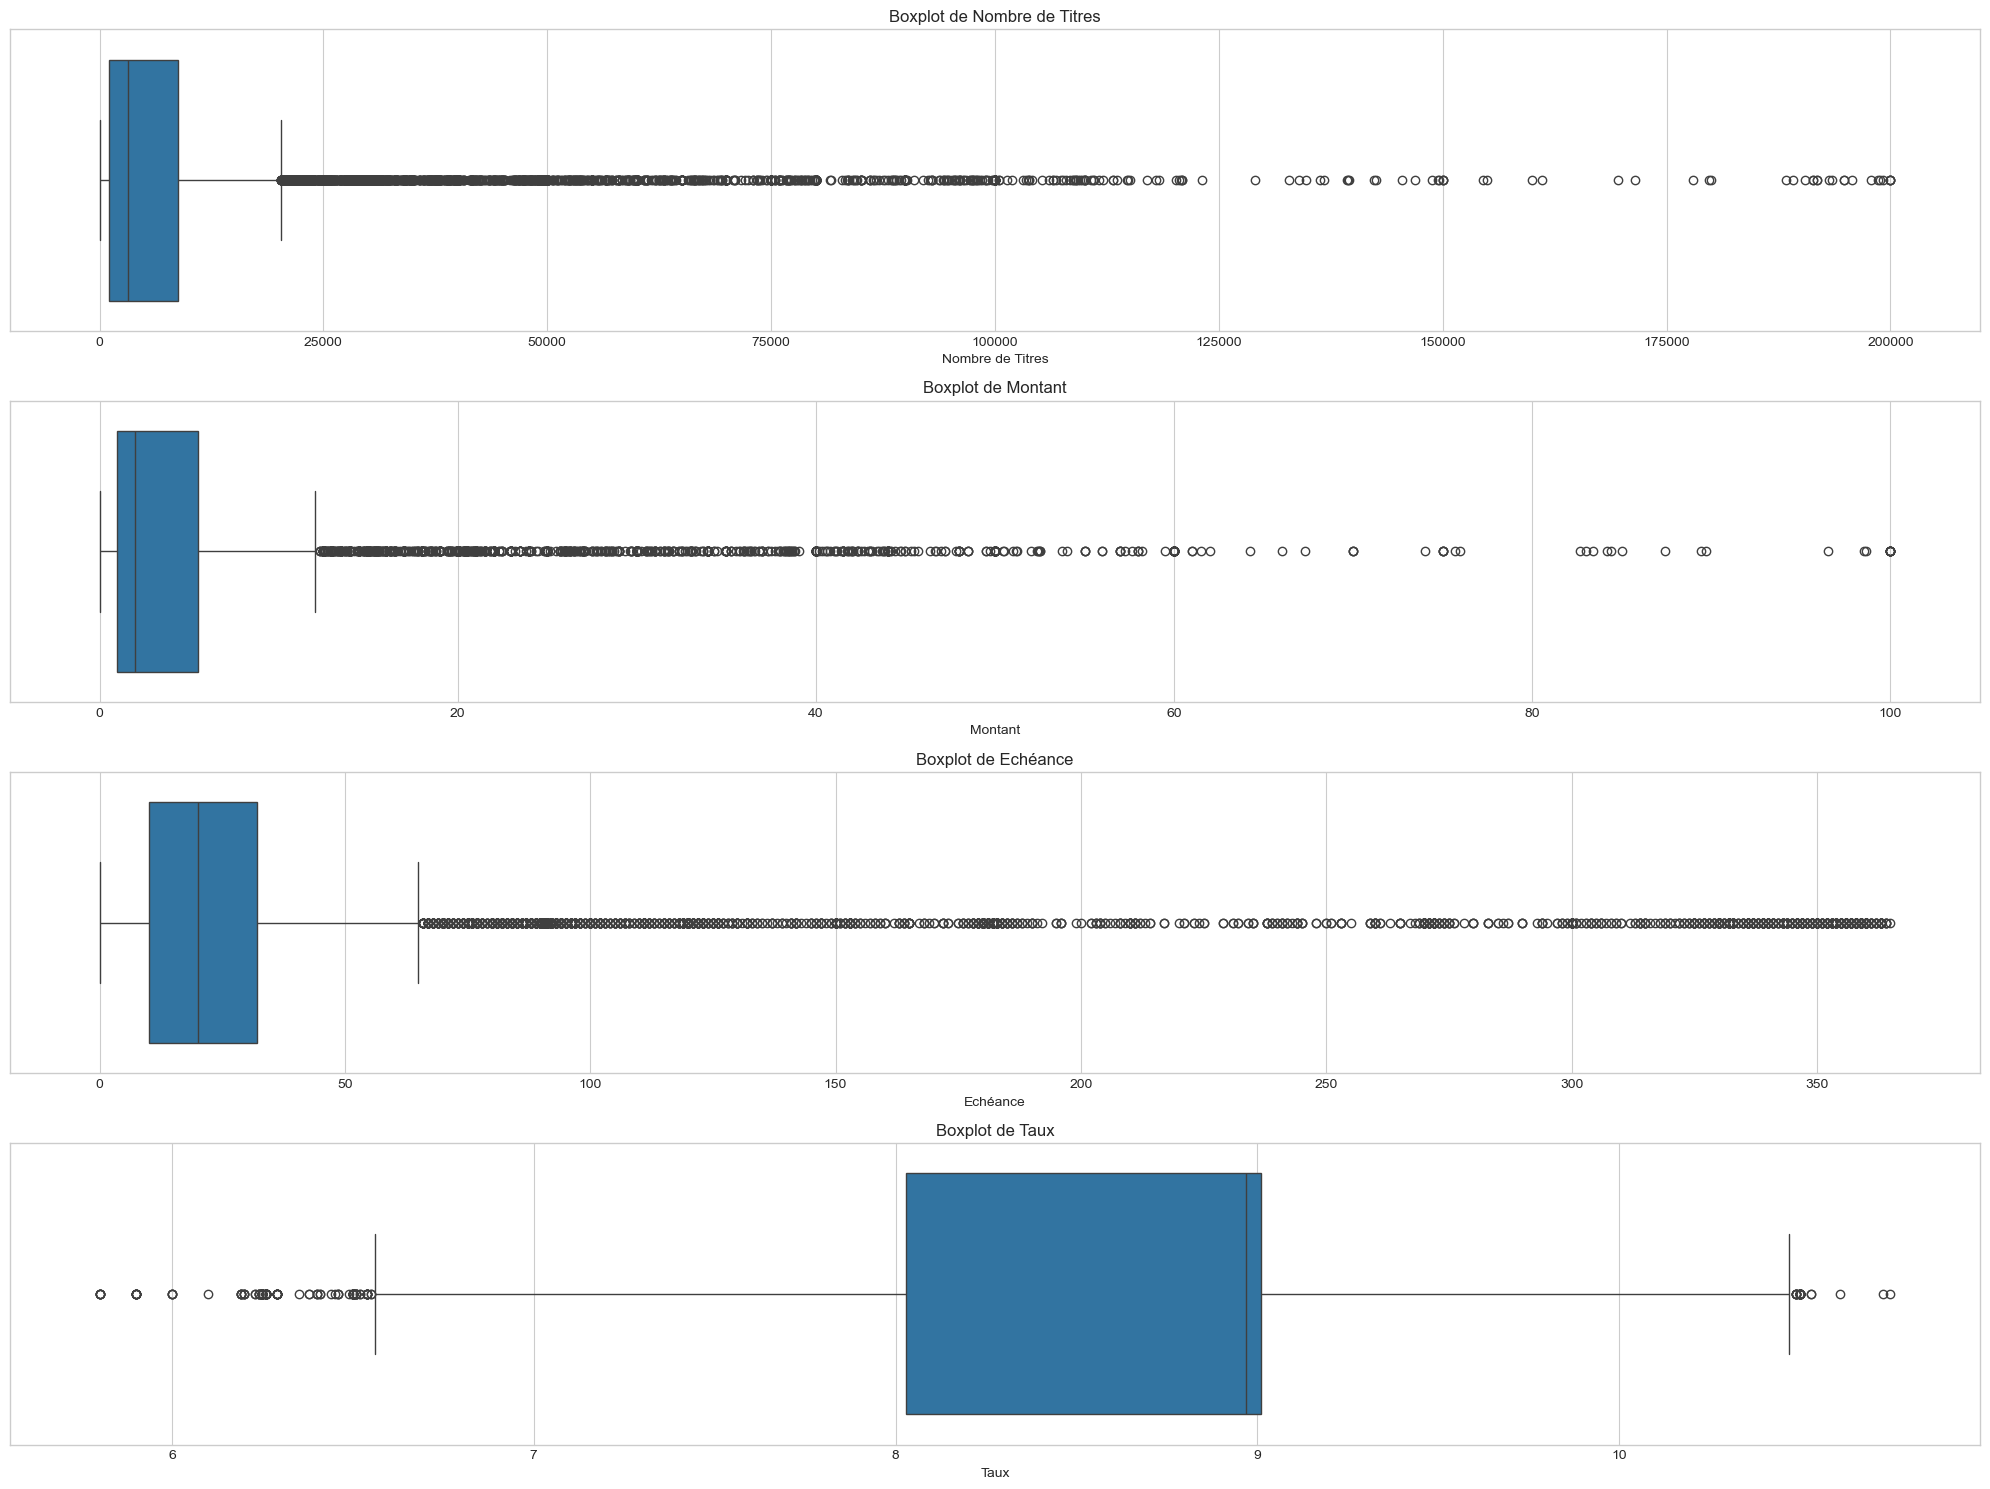

In [35]:
plt.figure(figsize=(20, 15))
for i, col in enumerate(colonnes):
    plt.subplot(4, 1, i+1)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot de {col}")
plt.tight_layout()
plt.show()


In [36]:
colonnes = ['Nombre de Titres', 'Montant', 'Echéance', 'Taux']

# Taille des plots
plt.style.use("seaborn-v0_8-whitegrid")

for col in colonnes:
    print(f"\n📊 Analyse de la colonne : {col}")

    # Intervalle contenant la majorité des données (ex : 90%)
    q_low = df[col].quantile(0.05)
    q_high = df[col].quantile(0.95)
    print(f"📌 Intervalle réel contenant 90% des données : [{q_low:.2f}, {q_high:.2f}]")

    # Outliers basés sur IQR
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    print(f"🚨 Nombre d'outliers détectés (IQR) : {outliers.count()}")

    # Statistiques complémentaires
    print(f"📉 Min réel : {df[col].min():.2f}")
    print(f"📈 Max réel : {df[col].max():.2f}")
    print(f"📊 Moyenne : {df[col].mean():.2f}")
    print(f"📍 Médiane : {df[col].median():.2f}")


📊 Analyse de la colonne : Nombre de Titres
📌 Intervalle réel contenant 90% des données : [280.00, 40000.00]
🚨 Nombre d'outliers détectés (IQR) : 2002
📉 Min réel : 1.00
📈 Max réel : 200000.00
📊 Moyenne : 8872.55
📍 Médiane : 3128.50

📊 Analyse de la colonne : Montant
📌 Intervalle réel contenant 90% des données : [0.22, 18.00]
🚨 Nombre d'outliers détectés (IQR) : 1538
📉 Min réel : 0.00
📈 Max réel : 100.00
📊 Moyenne : 4.87
📍 Médiane : 2.00

📊 Analyse de la colonne : Echéance
📌 Intervalle réel contenant 90% des données : [6.00, 147.00]
🚨 Nombre d'outliers détectés (IQR) : 3032
📉 Min réel : 0.00
📈 Max réel : 365.00
📊 Moyenne : 40.11
📍 Médiane : 20.00

📊 Analyse de la colonne : Taux
📌 Intervalle réel contenant 90% des données : [7.25, 9.89]
🚨 Nombre d'outliers détectés (IQR) : 241
📉 Min réel : 5.80
📈 Max réel : 10.75
📊 Moyenne : 8.63
📍 Médiane : 8.97


In [37]:
colonnes_numeriques = df.select_dtypes(include=[np.number]).columns

for col in colonnes_numeriques:
    nb_negatifs = (df[col] < 0).sum()
    print(f"➖ {col} : {nb_negatifs} valeur(s) négative(s)")


➖ Nombre de Titres : 0 valeur(s) négative(s)
➖ Montant : 0 valeur(s) négative(s)
➖ Echéance : 0 valeur(s) négative(s)
➖ Taux : 0 valeur(s) négative(s)


c:\Users\zizou\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


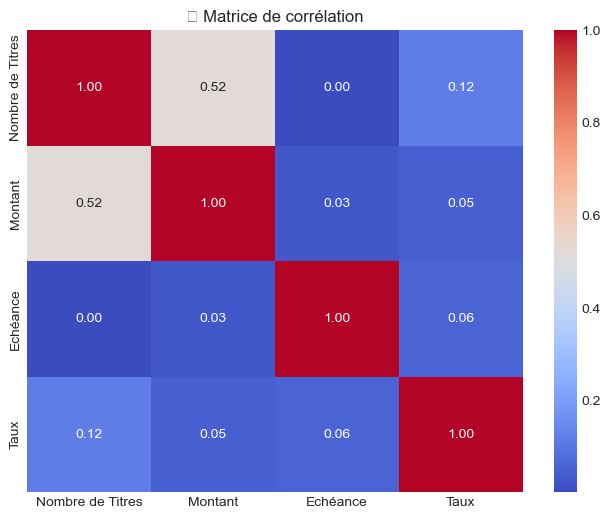

In [38]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[colonnes].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("🔗 Matrice de corrélation")
plt.show()
